In [1]:
#Importacion de libreria
import pandas as pd

Se realiza la fase de preprocesamiento y extracción de características del dataset para prepararlo estructuralmente para un modelo de clasificación. 
Su función principal es transformar los datos brutos en variables vectorizables, aislando los códigos médicos y binarizando las categorías demográficas.

In [2]:
corpus=[]
target=[]
edad=[]
sexo=[]
severidad=[]
archivo=open("dataset_elpino.csv",encoding="utf-8")
header=archivo.readline().strip().split(";")
features=[]
for col in header:
    col=col.split("-")[0].strip()
    if col.startswith("Diag") or col.startswith("Proc"):
        col=col.split(" ")
        col=col[0]+col[1]
    features.append(col)
for linea in archivo:
    row=[]
    linea=linea.strip().split(";")
    for i in range(len(linea)):
        col=linea[i].split("-")[0].strip()
        if i==67:
            grd=col
            #target.append(grd[-1])
            target.append(grd)
        elif i==66:
            sexo.append(1 if col=="Mujer" else 0)
        elif i==65:
            edad.append(int(col))
        else:
            row.append(col)
    corpus.append(row)

In [3]:
#Lista de lista con los datos limpios
corpus[0]

['A41.8',
 'B37.6',
 'I39.8',
 'N10',
 'B96.1',
 'L89.9',
 'L08.9',
 'B96.2',
 'A41.5',
 'J86.9',
 'U07.1',
 'Y95',
 'N18.5',
 'E87.1',
 'D64.9',
 'G82.2',
 'N31.9',
 'I10',
 'K70.4',
 'F19.2',
 'F10.2',
 'E46',
 'G40.9',
 'L21.9',
 'Z93.5',
 'Z93.3',
 'Z99.2',
 'Z91.6',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '86.28',
 '34.91',
 '88.38',
 '87.41',
 '88.75',
 '88.01',
 '88.43',
 '88.41',
 '87.44',
 '99.29',
 '99.19',
 '99.18',
 '99.21',
 '99.26',
 '99.23',
 '93.94',
 '89.52',
 '90.59',
 '89.65',
 '39.95',
 '39.95',
 '99.04',
 '90.39',
 '99.84',
 '88.72',
 '90.42',
 '90.52',
 '91.39',
 '91.33',
 '87.03']

In [4]:
features

['Diag01',
 'Diag02',
 'Diag03',
 'Diag04',
 'Diag05',
 'Diag06',
 'Diag07',
 'Diag08',
 'Diag09',
 'Diag10',
 'Diag11',
 'Diag12',
 'Diag13',
 'Diag14',
 'Diag15',
 'Diag16',
 'Diag17',
 'Diag18',
 'Diag19',
 'Diag20',
 'Diag21',
 'Diag22',
 'Diag23',
 'Diag24',
 'Diag25',
 'Diag26',
 'Diag27',
 'Diag28',
 'Diag29',
 'Diag30',
 'Diag31',
 'Diag32',
 'Diag33',
 'Diag34',
 'Diag35',
 'Proced01',
 'Proced02',
 'Proced03',
 'Proced04',
 'Proced05',
 'Proced06',
 'Proced07',
 'Proced08',
 'Proced09',
 'Proced10',
 'Proced11',
 'Proced12',
 'Proced13',
 'Proced14',
 'Proced15',
 'Proced16',
 'Proced17',
 'Proced18',
 'Proced19',
 'Proced20',
 'Proced21',
 'Proced22',
 'Proced23',
 'Proced24',
 'Proced25',
 'Proced26',
 'Proced27',
 'Proced28',
 'Proced29',
 'Proced30',
 'Edad en años',
 'Sexo (Desc)',
 'GRD']

In [5]:
#Transformamos los datos en una estructura tabular de pandas
df=pd.DataFrame(corpus,columns=features[:-3])
df["GRD"]=target
df

,Diag01,Diag02,Diag03,Diag04,Diag05,Diag06,Diag07,Diag08,Diag09,Diag10,...,Proced22,Proced23,Proced24,Proced25,Proced26,Proced27,Proced28,Proced29,Proced30,GRD
0,A41.8,B37.6,I39.8,N10,B96.1,L89.9,L08.9,B96.2,A41.5,J86.9,...,99.04,90.39,99.84,88.72,90.42,90.52,91.39,91.33,87.03,184103
1,U07.1,J12.8,R06.0,R05,R50.9,Z29.0,Z01.7,J96.00,J94.2,J92.9,...,91.69,87.44,91.62,90.43,91.39,90.52,91.32,96.59,90.99,041013
2,K56.5,R57.2,R57.1,J80,Y95,J15.0,U82.2,B95.6,B96.8,B37.1,...,91.33,90.39,99.84,91.73,90.53,99.26,89.39,89.66,89.65,041013
3,K76.8,K66.1,N18.5,D64.9,E87.5,E87.2,J81,N17.8,J44.9,R41.0,...,96.59,94.19,57.94,00.13,00.17,99.04,99.18,99.21,99.23,041023
4,T81.0,Y83.2,S31.1,S36.80,W31.62,J96.09,J15.0,U82.2,U07.1,N39.0,...,99.21,99.29,90.52,91.39,91.32,93.90,99.15,96.59,45.13,041023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14556,E10.1,J45.9,F10.2,F17.2,Z91.1,,,,,,...,,,,,,,,,,104101
14557,S09.9,W18.24,R55,,,,,,,,...,,,,,,,,,,014242
14558,K92.1,I10,E11.9,I50.9,K25.9,M16.9,G47.3,Z99.8,,,...,,,,,,,,,,064182
14559,E78.1,I10,Z92.2,,,,,,,,...,,,,,,,,,,104121


In [6]:
#Visualizacion de la informacion del data set
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14561 entries, 0 to 14560
Data columns (total 66 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Diag01    14561 non-null  str  
 1   Diag02    14561 non-null  str  
 2   Diag03    14561 non-null  str  
 3   Diag04    14561 non-null  str  
 4   Diag05    14561 non-null  str  
 5   Diag06    14561 non-null  str  
 6   Diag07    14561 non-null  str  
 7   Diag08    14561 non-null  str  
 8   Diag09    14561 non-null  str  
 9   Diag10    14561 non-null  str  
 10  Diag11    14561 non-null  str  
 11  Diag12    14561 non-null  str  
 12  Diag13    14561 non-null  str  
 13  Diag14    14561 non-null  str  
 14  Diag15    14561 non-null  str  
 15  Diag16    14561 non-null  str  
 16  Diag17    14561 non-null  str  
 17  Diag18    14561 non-null  str  
 18  Diag19    14561 non-null  str  
 19  Diag20    14561 non-null  str  
 20  Diag21    14561 non-null  str  
 21  Diag22    14561 non-null  str  
 22  Diag23   

In [7]:
#Visualizacion de los datos en el target de GRD
df["GRD"].value_counts()[:20]

GRD
146101    813
146121    639
146131    538
158171    389
134161    325
071141    317
044153    287
061131    252
041023    248
146102    244
044163    229
131111    226
131201    222
054123    204
146122    187
146103    163
061201    154
044183    145
146132    140
131301    139
Name: count, dtype: int64

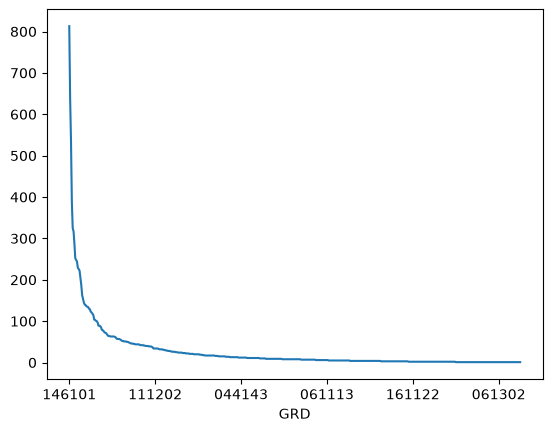

In [8]:
#Visualizacion de la cantidad de datos por GRD
df["GRD"].value_counts().plot();

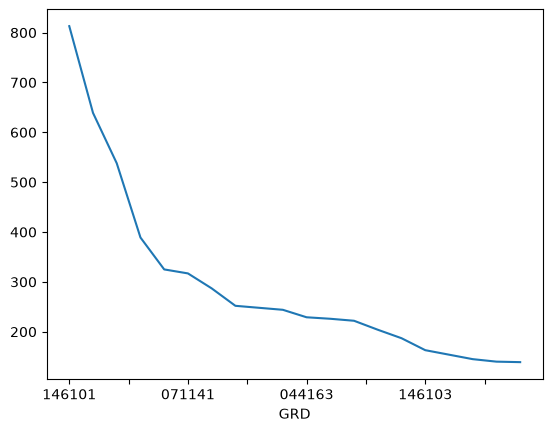

In [9]:
df["GRD"].value_counts()[:20].plot();

In [10]:
#Al visualizar que la mayor cantidad de datos se concentra en 3 GDR, se seleccionan estos 3 para el analisis y evitar el desbalanceo con las otras categorias.
filtro=(df["GRD"]=='146101') | (df["GRD"]=='146102') | (df["GRD"]=='146103')
#Aplicamos el filtro
df[filtro]

,Diag01,Diag02,Diag03,Diag04,Diag05,Diag06,Diag07,Diag08,Diag09,Diag10,...,Proced22,Proced23,Proced24,Proced25,Proced26,Proced27,Proced28,Proced29,Proced30,GRD
38,O32.1,O42.1,O82.0,O34.0,O98.1,A53.9,O99.3,F12.2,O99.2,E66.9,...,,,,,,,,,,146102
100,O61.0,O82.1,O24.4,O26.0,Z37.0,Z38.0,Z39.0,Z39.1,Z39.2,,...,,,,,,,,,,146101
111,O34.2,O82.1,O24.4,O26.0,Z37.0,Z38.0,Z39.0,Z39.1,Z39.2,,...,,,,,,,,,,146101
139,O14.0,O66.4,O82.1,O26.0,Z35.3,Z64.0,Z88.6,Z37.0,Z38.0,Z39.0,...,,,,,,,,,,146101
141,O61.0,O82.1,O99.2,E66.9,Z37.0,Z38.0,Z39.0,Z39.1,Z39.2,,...,,,,,,,,,,146101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14534,O61.0,O82.1,Z37.0,Z38.0,Z39.0,Z39.1,Z39.2,Z35.1,Z92.4,,...,,,,,,,,,,146102
14535,O61.0,O82.0,Z37.0,Z38.0,Z39.0,Z39.1,Z39.2,Z88.0,,,...,,,,,,,,,,146101
14538,O82.0,O99.0,O10.0,Z37.0,Z38.0,Z39.0,Z39.1,Z39.2,O62.2,,...,,,,,,,,,,146102
14539,O60.1,O82.1,O30.0,O99.2,E66.9,Z37.0,Z38.0,Z39.0,Z39.1,Z39.2,...,,,,,,,,,,146101


In [11]:
#crea una matriz que muestra cuántas veces un diagnóstico principal específico deriva en un GRD particular,
pd.crosstab(df[filtro]["GRD"],df["Diag01"],margins=True)

Diag01,O03.9,O06.3,O10.0,O10.9,O11,O13,O14.0,O14.1,O14.2,O14.9,...,O98.4,O98.5,O99.0,O99.2,O99.3,O99.5,O99.6,O99.8,Z35.4,All
GRD,,,,,,,,,,,,,,,,,,,,,
146101,0,1,5,2,14,9,5,22,3,2,...,1,0,2,1,0,0,0,1,1,813
146102,1,0,0,0,1,4,4,14,2,1,...,0,0,1,1,1,1,0,0,0,244
146103,0,0,0,0,4,0,0,23,2,1,...,0,35,0,0,0,0,1,0,0,163
All,1,1,5,2,19,13,9,59,7,4,...,1,35,3,2,1,1,1,1,1,1220


In [12]:
data=df[filtro]

In [13]:
#dos listas de texto que contienen los nombres exactos y estandarizados de las columnas para los diagnósticos y los procedimientos.

features_procedimientos=[]
features_diagnosticos=[]
for j in range(1,36):
    field="Diag"+str(j).zfill(2)
    features_diagnosticos.append(field)
for j in range(1,31):
    field="Proced"+str(j).zfill(2)
    features_procedimientos.append(field)

In [14]:
#Este bloque de código construye un diccionario de frecuencias y 
#extrae el "vocabulario" único de todos los códigos médicos 
# (diagnósticos y procedimientos) presentes en el dataset, 
# aplicando técnicas de Procesamiento de Lenguaje Natural (NLP) 
# a los historiales clínicos.
procedimientos={}
diagnosticos={}
for i, row in data.iterrows():
    for j in range(1,36):
        field="Diag"+str(j).zfill(2)
        if row[field] not in diagnosticos:
            diagnosticos[row[field]]=1
        else:
            diagnosticos[row[field]]+=1
    for j in range(1,31):
        field="Proced"+str(j).zfill(2)
        if row[field] not in procedimientos:
            procedimientos[row[field]]=1
        else:
            procedimientos[row[field]]+=1
token_diagnosticos=list(diagnosticos.keys())
token_procedimientos=list(procedimientos.keys())
vocabulario=len(token_diagnosticos)+len(token_procedimientos)+1
print("Cantidad de valores unicos")
print("Diagnósticos: ",len(token_diagnosticos))
print("Procedimientos: ",len(token_procedimientos))
print("Vocabulario: ",vocabulario)

#Al conocer exactamente cuántos códigos distintos existen, puedes crear un índice 
# numérico (donde por ejemplo, el código COVID-19 pasa a ser el ID "142"). 
# Esto es un requisito matemático estricto antes de pasar las variables de texto 
# a un algoritmo de clasificación o a una matriz de One-Hot Encoding.

Cantidad de valores unicos
Diagnósticos:  377
Procedimientos:  155
Vocabulario:  533


In [15]:
#tokenización final de los datos, transformando el texto crudo de los códigos médicos 
# en secuencias de números enteros únicos, un paso estricto para que los algoritmos 
# puedan procesar la información.
token_rows=[]
for i, row in data.iterrows():
    token_row=[]
    for j in range(1,36):
        field="Diag"+str(j).zfill(2)
        token_row.append(1+token_diagnosticos.index(row[field]))
    for j in range(1,31):
        field="Proced"+str(j).zfill(2)
        token_row.append(1+377+token_procedimientos.index(row[field]))
    token_rows.append(token_row)


In [16]:
#Importamos las librerias para los modelos
import tensorflow as tf
from keras.layers import Attention, Input, Dense, Embedding, Flatten, LSTM
from keras.models import Model,Sequential
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from datetime import datetime
import numpy as np
from keras.utils import pad_sequences

X=pad_sequences(token_rows)

Transformamos la variable objetivo (GRD) en una matriz binaria matemática mediante un proceso de One-Hot Encoding, dejándola en el formato exacto que exige una red neuronal para tareas de clasificación multiclase.

In [17]:

Y=data["GRD"].apply(lambda x: int(x)).to_numpy()
encoder=LabelEncoder()
encoder.fit(Y)
Y=encoder.transform(Y)
Y=np.asarray(Y)
Y=Y.reshape(-1,1)
encoder=OneHotEncoder()
encoder.fit(Y)
Y=encoder.transform(Y).todense()
print(Y.shape)
print(X.shape)

(1220, 3)
(1220, 65)


Partición del dataset y de la transformación de las dimensiones matemáticas de los datos (tensores) para hacerlos compatibles con arquitecturas de redes neuronales secuenciales, como las redes recurrentes (LSTM) o convolucionales unidimensionales (Conv1D).

In [18]:
x_train,x_val,y_train,y_val=train_test_split(X,Y,random_state=0)
x_train_s=x_train.reshape(-1,65,1)
x_val_s=x_val.reshape(-1,65,1)

## Red neuronal recurrente (RNN)

In [19]:
modelo_emb=Sequential()
modelo_emb.add(Embedding(input_dim=vocabulario,output_dim=64))
modelo_emb.add(LSTM(32))
modelo_emb.add(Dense(3,activation="softmax"))
modelo_emb.compile(optimizer="Adam",loss="categorical_crossentropy",metrics=["acc"])
modelo_emb.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
#Ejecucion de la red neuronal
tag="emb"+datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = "logs/fit/" + tag
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
spam_emb = modelo_emb.fit(x_train, y_train, validation_data=(x_val,y_val), batch_size=32, epochs=16,verbose=2,callbacks=[tensorboard_callback])

Epoch 1/16
29/29 - 3s - 103ms/step - acc: 0.6656 - loss: 0.9098 - val_acc: 0.6689 - val_loss: 0.8681
Epoch 2/16
29/29 - 1s - 17ms/step - acc: 0.6656 - loss: 0.8525 - val_acc: 0.6689 - val_loss: 0.8540
Epoch 3/16
29/29 - 1s - 19ms/step - acc: 0.6689 - loss: 0.8493 - val_acc: 0.6689 - val_loss: 0.8500
Epoch 4/16
29/29 - 1s - 18ms/step - acc: 0.6689 - loss: 0.8441 - val_acc: 0.6721 - val_loss: 0.8211
Epoch 5/16
29/29 - 1s - 17ms/step - acc: 0.6689 - loss: 0.8235 - val_acc: 0.6754 - val_loss: 0.7665
Epoch 6/16
29/29 - 1s - 18ms/step - acc: 0.7049 - loss: 0.7572 - val_acc: 0.7148 - val_loss: 0.8428
Epoch 7/16
29/29 - 1s - 17ms/step - acc: 0.7104 - loss: 0.7605 - val_acc: 0.6984 - val_loss: 0.7892
Epoch 8/16
29/29 - 1s - 17ms/step - acc: 0.6842 - loss: 0.7824 - val_acc: 0.7311 - val_loss: 0.7465
Epoch 9/16
29/29 - 1s - 21ms/step - acc: 0.6918 - loss: 0.7662 - val_acc: 0.7410 - val_loss: 0.7052
Epoch 10/16
29/29 - 1s - 24ms/step - acc: 0.7191 - loss: 0.7100 - val_acc: 0.7869 - val_loss: 0.561

In [21]:
#Guardamos el modelo y sus parametros
modelo_emb.save('modelo{0}.keras'.format(tag))
print('modelo{0}.keras'.format(tag))

modeloemb20260906-222126.keras


In [22]:
modelo_emb=tf.keras.models.load_model('modeloemb20260906-191922.keras')

In [23]:
y_pred_probs=modelo_emb.predict(x_val)
y_pred=np.argmax(y_pred_probs,axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [24]:
#Importamos librerias
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

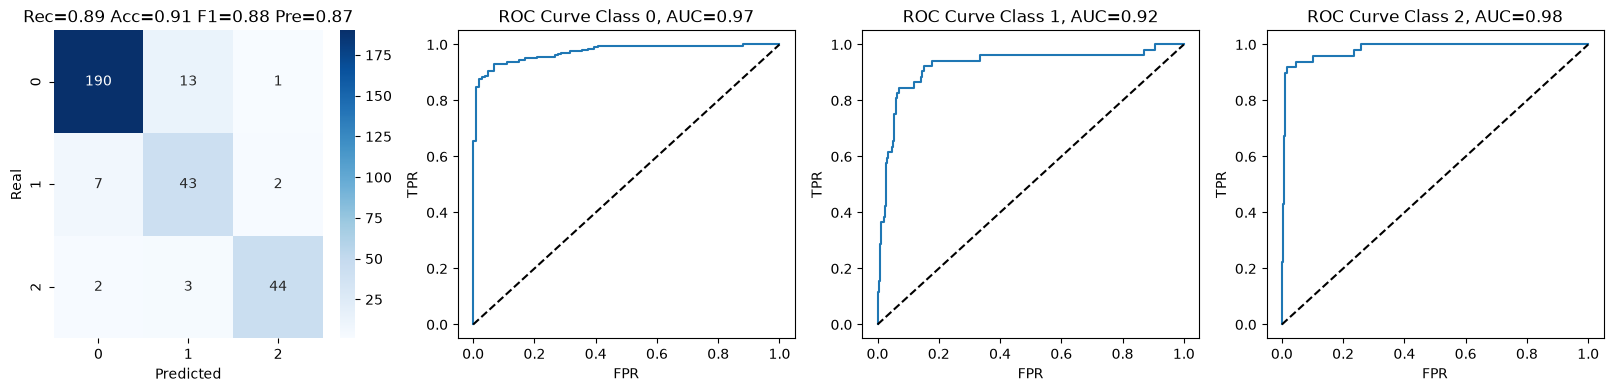

In [25]:
fig, axes = plt.subplots(1,4)
fig.set_size_inches(20, 4)

y_val1d=np.squeeze(np.asarray(np.argmax(y_val,axis=1)))

matriz = confusion_matrix(y_val1d, 
                          y_pred)    
ax=axes[0]
sns.heatmap(matriz, annot=True, ax = ax, cmap="Blues",fmt="d");
ax.set_title("Rec="+str(round(recall_score(y_val1d,y_pred,average="macro"),2))+
        " Acc="+str(round(accuracy_score(y_val1d,y_pred),2))+
        " F1="+str(round(f1_score(y_val1d, y_pred,average="macro"),2))+
        " Pre="+str(round(precision_score(y_val1d, y_pred,average="macro"),2)));
axes[0].set_xlabel('Predicted');
axes[0].set_ylabel('Real');

fpr = {}
tpr = {}
roc_auc = {}
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(np.asarray(y_val[:, i]), np.asarray(y_pred_probs[:, i]))
    roc_auc[i] = auc(fpr[i], tpr[i])

for i in range(3):
    axes[i+1].plot(fpr[i], tpr[i])
    axes[i+1].plot([0, 1], [0, 1], 'k--')
    axes[i+1].set_xlabel('FPR')
    axes[i+1].set_ylabel('TPR')
    axes[i+1].set_title('ROC Curve Class {0}, AUC={1}'.format(i,round(roc_auc[i],2)))

In [26]:
y_pred1d=label_binarize(np.argmax(y_pred_probs,axis=1),classes=[0,1,2])

In [27]:
for i in range(3):
    print("ACC=",round(accuracy_score(np.squeeze(np.asarray(y_val[:,i])), y_pred1d[:,i]),2),
        "PRE=",round(precision_score(np.squeeze(np.asarray(y_val[:,i])), y_pred1d[:,i]),2),
        "REC=",round(recall_score(np.squeeze(np.asarray(y_val[:,i])), y_pred1d[:,i]),2))

ACC= 0.92 PRE= 0.95 REC= 0.93
ACC= 0.92 PRE= 0.73 REC= 0.83
ACC= 0.97 PRE= 0.94 REC= 0.9


Matrices de confusión individuales, evaluando el desempeño de la red neuronal para cada uno de los 3 GRD bajo un enfoque "Uno contra Todos" (One-vs-Rest).

In [28]:
from sklearn.metrics import multilabel_confusion_matrix
multilabel_confusion_matrix(y_val1d,y_pred,labels=[0,1,2])

array([[[ 92,   9],
        [ 14, 190]],

       [[237,  16],
        [  9,  43]],

       [[253,   3],
        [  5,  44]]], dtype=int64)

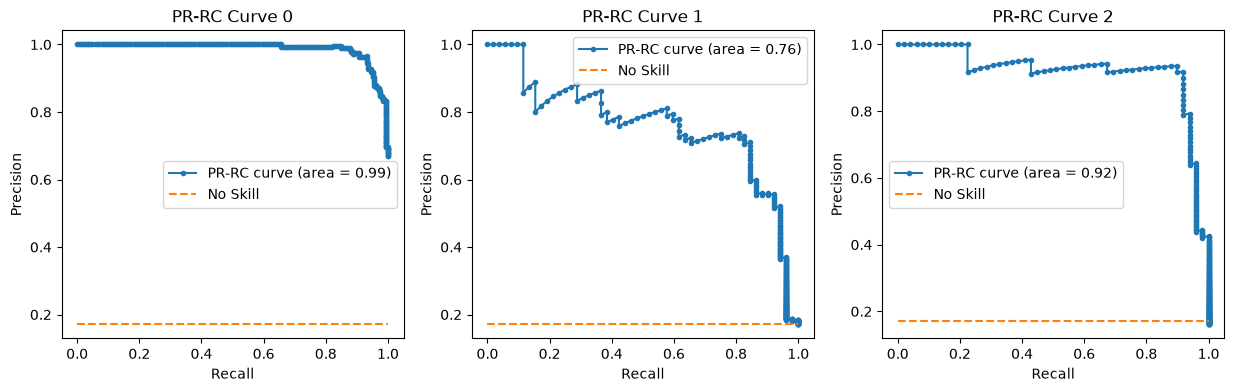

In [29]:
fig, axes = plt.subplots(1,3)
fig.set_size_inches(15, 4)

for i in range(3):
    lr_precision, lr_recall, thresholds_pr = precision_recall_curve(np.asarray(y_val[:,i]), np.asarray(y_pred_probs[:,i]))
    filtro=np.squeeze(np.asarray(y_val[:,1]==1))
    no_skill = len(y_val[filtro]) / len(y_val)
    p=i
    axes[p].plot(lr_recall, lr_precision, marker='.', label='PR-RC curve (area = %0.2f)' % auc(lr_recall,lr_precision))
    axes[p].plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')
    axes[p].set_xlabel('Recall')
    axes[p].set_ylabel('Precision')
    axes[p].set_title('PR-RC Curve %i' % i)
    axes[p].legend();

In [30]:
test=pd.DataFrame(x_val,columns=features_diagnosticos+features_procedimientos)
test["y"]=np.argmax(y_val,axis=1)
test["yp"]=np.argmax(y_pred_probs,axis=1)

In [31]:
test[(test["y"]==1) & (test["yp"]==2)]

,Diag01,Diag02,Diag03,Diag04,Diag05,Diag06,Diag07,Diag08,Diag09,Diag10,...,Proced23,Proced24,Proced25,Proced26,Proced27,Proced28,Proced29,Proced30,y,yp
121,65,103,72,19,78,9,10,35,36,14,...,394,394,394,394,394,394,394,394,1,2
137,28,153,91,303,57,22,21,9,169,32,...,394,394,394,394,394,394,394,394,1,2


In [ ]:
import shap
#Calcula la explicabilidad de tu modelo
explainer = shap.KernelExplainer(modelo_emb.predict, x_val[:20])

In [34]:
shap_values = explainer.shap_values(x_val[:20])

  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

# Grafico de explicabilidad 
Eje Y (Características): Muestra los códigos de diagnóstico y procedimientos ordenados de mayor a menor importancia según el impacto que tuvieron en las predicciones del modelo.

Eje X (Valor Shapley): Muestra cuánto empuja una característica específica la probabilidad hacia el GRD evaluado. Los puntos hacia la derecha indican que ese código médico aumentó la probabilidad de pertenecer a ese grupo, mientras que los puntos hacia la izquierda la disminuyeron.

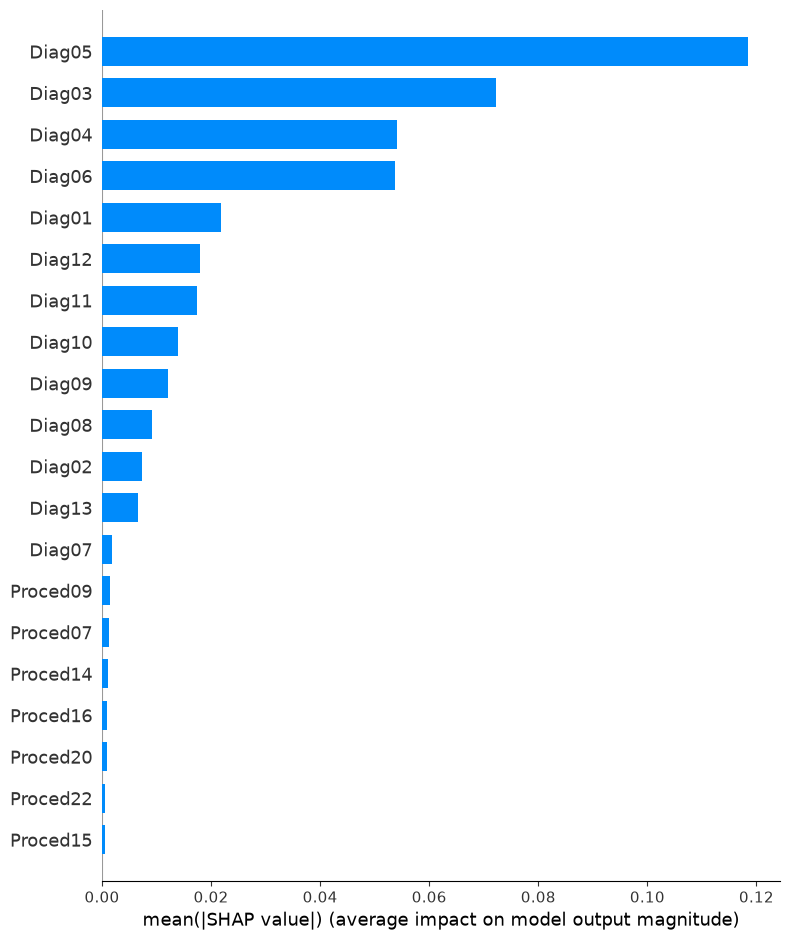

In [35]:
shap.summary_plot(shap_values[:,:,0], plot_type = 'bar',feature_names=features_diagnosticos+features_procedimientos)

In [ ]:
#Acota la inspección de los errores del modelo, filtrando exclusivamente a los 
# pacientes mal clasificados para mostrar de forma limpia sus primeros códigos 
# diagnósticos.
test[(test["y"]==1) & (test["yp"]==2)][["Diag01","Diag02","Diag03","Diag04","Diag05","Diag06"]]

,Diag01,Diag02,Diag03,Diag04,Diag05,Diag06
121,65,103,72,19,78,9
137,28,153,91,303,57,22


In [ ]:
#validación para analizar el comportamiento del modelo exclusivamente sobre 
# una categoría de pacientes.
filtro1=test[(test["y"]==1)]
filtro1

,Diag01,Diag02,Diag03,Diag04,Diag05,Diag06,Diag07,Diag08,Diag09,Diag10,...,Proced23,Proced24,Proced25,Proced26,Proced27,Proced28,Proced29,Proced30,y,yp
10,54,37,7,55,56,19,21,12,13,14,...,391,393,394,394,394,394,394,394,1,1
13,22,3,9,10,63,298,12,13,14,15,...,394,394,394,394,394,394,394,394,1,1
16,162,22,85,3,20,94,9,10,12,13,...,394,394,394,394,394,394,394,394,1,1
33,3,57,9,209,12,13,14,15,16,177,...,394,394,394,394,394,394,394,394,1,1
38,72,19,164,12,13,14,15,16,17,17,...,394,394,394,394,394,394,394,394,1,1
44,72,19,62,65,12,13,14,15,16,309,...,394,394,394,394,394,394,394,394,1,1
45,3,20,12,13,14,15,16,43,165,17,...,394,394,394,394,394,394,394,394,1,1
49,47,135,62,22,78,3,35,36,14,15,...,394,394,394,394,394,394,394,394,1,1
55,23,72,19,69,21,68,12,13,14,15,...,394,394,394,394,394,394,394,394,1,1
63,72,19,56,91,9,10,12,13,14,15,...,394,394,394,394,394,394,394,394,1,1


In [ ]:
#Analisis del porcentaje exacto de confianza que el modelo tuvo para cada categoría 
# de GRD en ese caso particular.

y_pred_probs[10]

array([0.16020691, 0.4547262 , 0.38506684], dtype=float32)

Este gráfico dibuja una barra horizontal donde cada código médico actúa como una fuerza positiva (que empuja al modelo a clasificar al paciente en ese GRD) o negativa (que lo aleja).

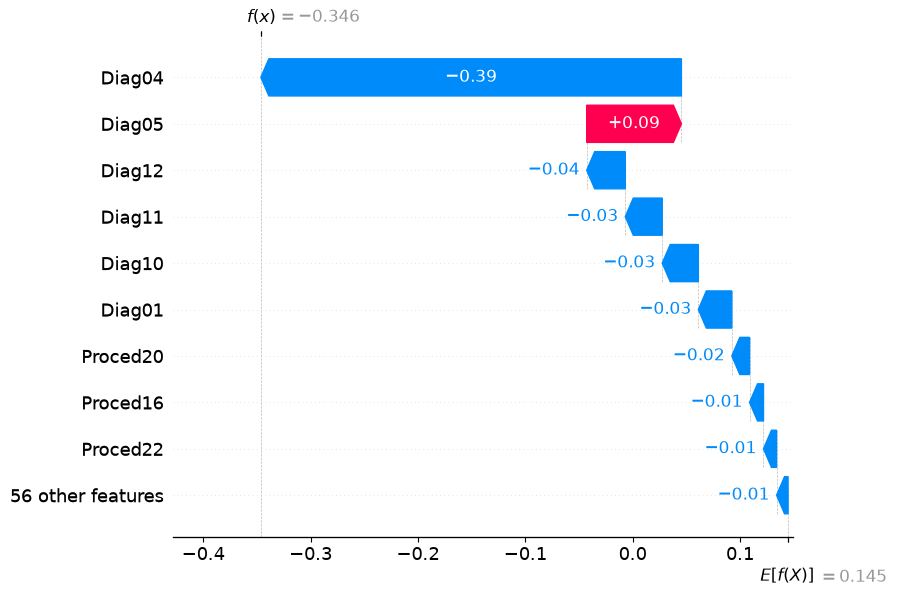

In [40]:
shap.plots._waterfall.waterfall_legacy(explainer.expected_value[1], shap_values[10,:,0], feature_names = features_diagnosticos+features_procedimientos)

In [ ]:
#Genera una tabla de contingencia cruzada para auditar estadísticamente cómo el 
# modelo está clasificando a los pacientes de una categoría real específica en 
# función de un diagnóstico secundario.
pd.crosstab(filtro1["Diag03"],filtro1["yp"])

yp,0,1,2
Diag03,,,
3,1,2,0
7,0,2,0
9,0,2,0
12,0,2,0
19,3,9,0
20,0,4,0
21,1,0,0
22,0,1,0
28,1,0,0


In [42]:
filtro1.loc[10]

Diag01       54
Diag02       37
Diag03        7
Diag04       55
Diag05       56
           ... 
Proced28    394
Proced29    394
Proced30    394
y             1
yp            1
Name: 10, Length: 67, dtype: int64

In [ ]:
#Código clínico real código CIE-10 que le corresponde al índice numérico 7
token_diagnosticos[7]

'F12.2'

In [ ]:
#onteo de frecuencias sobre el tercer diagnóstico (Diag03) de todos los pacientes 
# que pertenecen al GRD 1.
filtro1["Diag03"].value_counts()

Diag03
19     12
20      4
62      3
69      3
3       3
72      3
7       2
9       2
164     2
12      2
91      2
51      2
85      1
56      1
33      1
21      1
372     1
220     1
22      1
52      1
57      1
65      1
187     1
28      1
Name: count, dtype: int64

In [45]:
token_diagnosticos[18]

'O82.1'

In [46]:
data.query("Diag03=='O82.1'")["GRD"].value_counts()

GRD
146101    119
146102     46
146103     26
Name: count, dtype: int64

In [47]:
test["y"].value_counts()

y
0    204
1     52
2     49
Name: count, dtype: int64

## Decision Tree Classifer

In [48]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [49]:
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(x_train,np.asarray(np.argmax(y_train,axis=1)))

#Predict the response for test dataset
y_pred_probs = clf.predict_proba(x_val)
y_pred=np.argmax(y_pred_probs,axis=1)

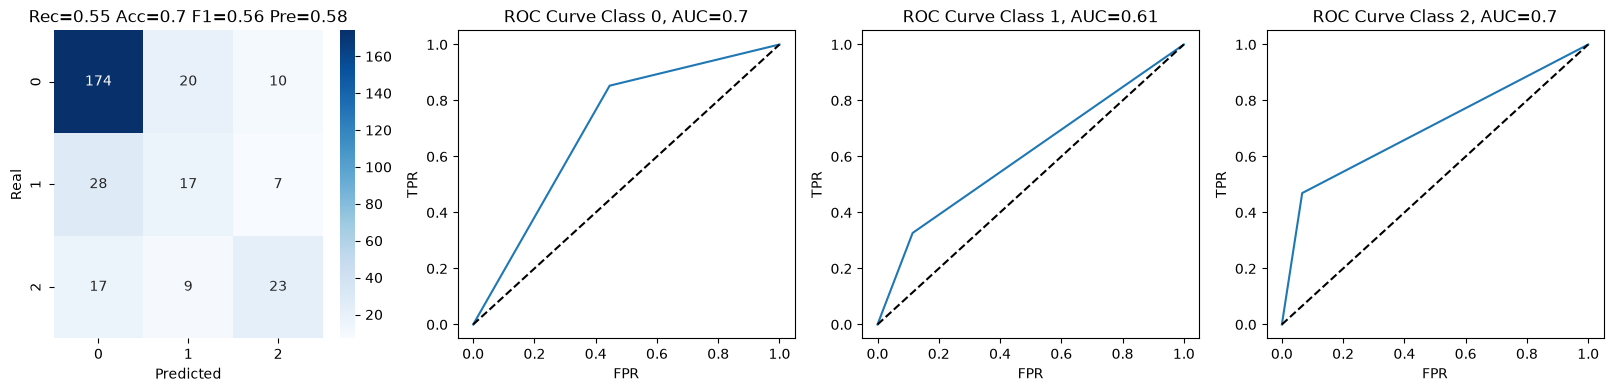

In [50]:
fig, axes = plt.subplots(1,4)
fig.set_size_inches(20, 4)

y_val1d=np.squeeze(np.asarray(np.argmax(y_val,axis=1)))

matriz = confusion_matrix(y_val1d, 
                          y_pred)    
ax=axes[0]
sns.heatmap(matriz, annot=True, ax = ax, cmap="Blues",fmt="d");
ax.set_title("Rec="+str(round(recall_score(y_val1d,y_pred,average="macro"),2))+
        " Acc="+str(round(accuracy_score(y_val1d,y_pred),2))+
        " F1="+str(round(f1_score(y_val1d, y_pred,average="macro"),2))+
        " Pre="+str(round(precision_score(y_val1d, y_pred,average="macro"),2)));
axes[0].set_xlabel('Predicted');
axes[0].set_ylabel('Real');

fpr = {}
tpr = {}
roc_auc = {}
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(np.asarray(y_val[:, i]), np.asarray(y_pred_probs[:, i]))
    roc_auc[i] = auc(fpr[i], tpr[i])

for i in range(3):
    axes[i+1].plot(fpr[i], tpr[i])
    axes[i+1].plot([0, 1], [0, 1], 'k--')
    axes[i+1].set_xlabel('FPR')
    axes[i+1].set_ylabel('TPR')
    axes[i+1].set_title('ROC Curve Class {0}, AUC={1}'.format(i,round(roc_auc[i],2)))

[Text(0.6022598140495867, 0.9722222222222222, 'x[2] <= 56.5\ngini = 0.497\nsamples = 915\nvalue = [609, 192, 114]'),
 Text(0.3452221074380165, 0.9166666666666666, 'x[1] <= 22.5\ngini = 0.407\nsamples = 722\nvalue = [541, 101, 80]'),
 Text(0.4737409607438016, 0.9444444444444444, 'True  '),
 Text(0.15495867768595042, 0.8611111111111112, 'x[9] <= 15.5\ngini = 0.212\nsamples = 471\nvalue = [416, 39, 16]'),
 Text(0.10165289256198347, 0.8055555555555556, 'x[3] <= 53.5\ngini = 0.521\nsamples = 83\nvalue = [52, 23, 8]'),
 Text(0.06776859504132231, 0.75, 'x[41] <= 412.0\ngini = 0.401\nsamples = 56\nvalue = [42, 10, 4]'),
 Text(0.06115702479338843, 0.6944444444444444, 'x[49] <= 394.5\ngini = 0.359\nsamples = 54\nvalue = [42, 10, 2]'),
 Text(0.04297520661157025, 0.6388888888888888, 'x[48] <= 410.5\ngini = 0.297\nsamples = 51\nvalue = [42, 8, 1]'),
 Text(0.026446280991735537, 0.5833333333333334, 'x[2] <= 6.0\ngini = 0.245\nsamples = 49\nvalue = [42, 7, 0]'),
 Text(0.013223140495867768, 0.527777777

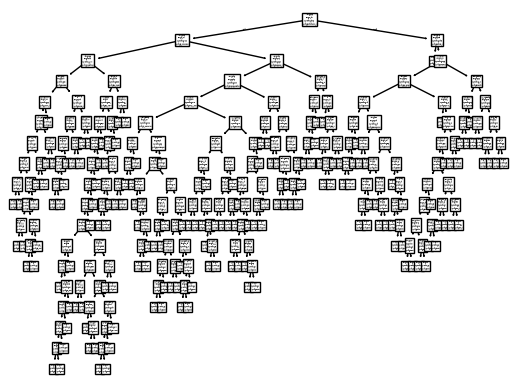

In [51]:
plot_tree(clf)